In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install optuna evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import optuna
import evaluate


In [4]:
path_dataset = '/content/drive/MyDrive/TFG/titles_data.jsonl'

with open(path_dataset, 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

print(f"Total dataset shape: {df.shape}")


Total dataset shape: (2312, 3)


In [5]:
# 1. Group Shuffle Split strategy based on 'id' -> Train, Eval, Test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42) # 70% train, 30% temp
train_idx, temp_idx = next(gss1.split(df, groups=df['group_id']))

df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42) # 15% eval, 15% test
eval_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['group_id']))

df_eval = df_temp.iloc[eval_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print(f"Train shape: {df_train.shape}, Evalu shape: {df_eval.shape}, Test shape: {df_test.shape}")

# Convert to HF Datasets
dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'eval': Dataset.from_pandas(df_eval),
    'test': Dataset.from_pandas(df_test)
})


Train shape: (1619, 3), Evalu shape: (346, 3), Test shape: (347, 3)


In [6]:
model_path = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_path)

id2label = {0: "IA", 1: "Human"}
label2id = {"IA": 0, "Human": 1}

def preprocess_function(examples):
    tokenized_inputs = tokenizer(examples["title"], truncation=True)
    tokenized_inputs["labels"] = examples["is_real"]
    return tokenized_inputs

tokenized_data = dataset_dict.map(preprocess_function, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1619 [00:00<?, ? examples/s]

Map:   0%|          | 0/346 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

In [7]:
# 3. Robust metric computation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if np.isnan(predictions).any():
        print("NaN found in predictions before probability conversion! Replacing with 0.")
        predictions = np.nan_to_num(predictions)

    predicted_classes = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predicted_classes, average='macro', zero_division=0)
    acc = accuracy_score(labels, predicted_classes)

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall
    }


In [8]:
# Function to initialize model for Hyperparameter Search
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        model_path, num_labels=2, id2label=id2label, label2id=label2id
    )


In [9]:
# Base Training arguments for sweep
training_args = TrainingArguments(
    output_dir="./temp_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    max_grad_norm=1.0,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    per_device_train_batch_size=8, # default
    per_device_eval_batch_size=8,
    num_train_epochs=3 # keeping it lower for sweep, then we can fine-tune longer
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["eval"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
# 4. Hyperparameter Search (Optuna)
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-6, 1e-4, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1)
    }

print("Starting Hyperparameter Search...")
best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=5 # Increase n_trials for a more thorough search
)

print("Best Run:", best_run)


[I 2026-03-08 18:07:10,561] A new study created in memory with name: no-name-550327ff-2966-4a65-b110-4c483eb1fce7


Starting Hyperparameter Search...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.690177,0.677710,0.543353,0.430542,0.732893,0.545944
2,0.602687,0.457601,0.823699,0.821431,0.842688,0.824379
3,0.405162,0.365283,0.855491,0.855371,0.857119,0.855687
4,0.369423,0.355957,0.864162,0.864152,0.864423,0.864241


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Best Run: BestRun(run_id='4', objective=3.5779412569455276, hyperparameters={'learning_rate': 3.625048445779734e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.09218103376963359}, run_summary=None)


In [11]:
# 5. Final Training with Best Hyperparameters
for n, v in best_run.hyperparameters.items():
    setattr(trainer.args, n, v)

print("Starting final training with best hyperparameters...")
trainer.train()


Starting final training with best hyperparameters...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.468542,0.416233,0.881503,0.881335,0.884253,0.881750
2,0.288213,0.519450,0.869942,0.869915,0.870073,0.869888
3,0.165237,0.539597,0.893064,0.892740,0.898727,0.893411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=609, training_loss=0.30733067178961093, metrics={'train_runtime': 83.5917, 'train_samples_per_second': 58.104, 'train_steps_per_second': 7.285, 'total_flos': 68159124446520.0, 'train_loss': 0.30733067178961093, 'epoch': 3.0})

In [12]:
# 6. Evaluation on Test Set
test_results = trainer.evaluate(tokenized_data["test"])
print("Test Set Results:", test_results)


Test Set Results: {'eval_loss': 0.4375276267528534, 'eval_accuracy': 0.899135446685879, 'eval_f1_macro': 0.8989205429743743, 'eval_precision_macro': 0.9029165269862555, 'eval_recall_macro': 0.8992757956281974, 'eval_runtime': 0.7772, 'eval_samples_per_second': 446.493, 'eval_steps_per_second': 56.616, 'epoch': 3.0}


Classification Report:
              precision    recall  f1-score   support

          IA       0.86      0.95      0.90       173
       Human       0.94      0.85      0.89       174

    accuracy                           0.90       347
   macro avg       0.90      0.90      0.90       347
weighted avg       0.90      0.90      0.90       347



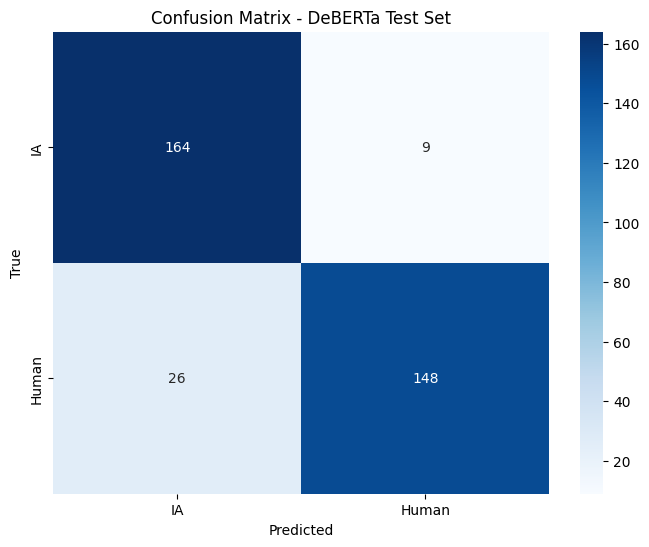

In [13]:
# 7. Predictions, Visualizations, and Stats
predictions, labels, metrics = trainer.predict(tokenized_data["test"])
predicted_classes = np.argmax(predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(labels, predicted_classes, target_names=["IA", "Human"], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(labels, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["IA", "Human"], yticklabels=["IA", "Human"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - DeBERTa Test Set')
plt.show()


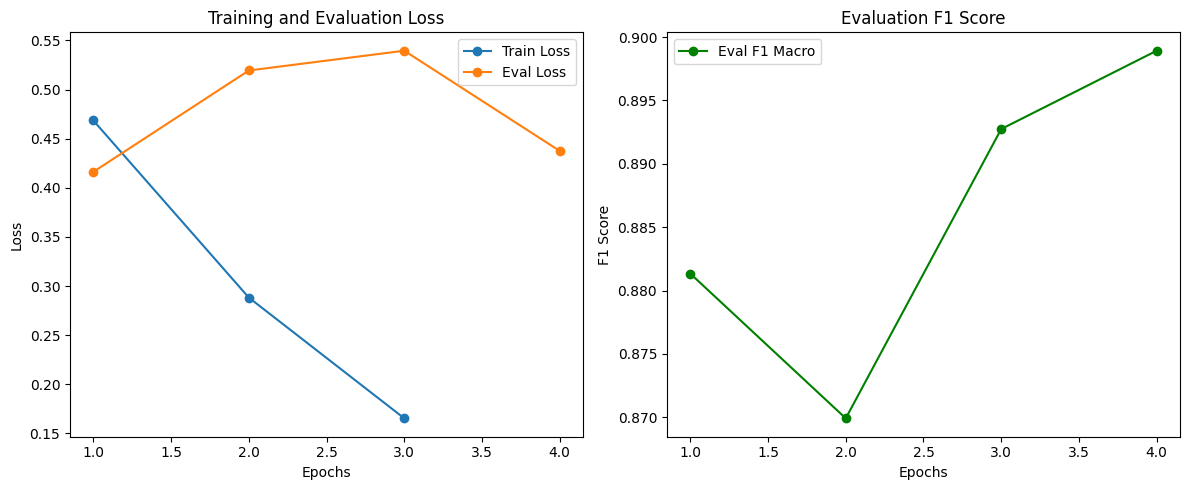

In [14]:
# Training history visualization
log_history = trainer.state.log_history

train_loss = [log['loss'] for log in log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_f1 = [log['eval_f1_macro'] for log in log_history if 'eval_f1_macro' in log]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(range(1, len(eval_loss) + 1), eval_loss, label='Eval Loss', marker='o')
plt.title('Training and Evaluation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Eval F1
plt.subplot(1, 2, 2)
if eval_f1:
    plt.plot(range(1, len(eval_f1) + 1), eval_f1, label='Eval F1 Macro', marker='o', color='green')
    plt.title('Evaluation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()

plt.tight_layout()
plt.show()
